# 00 — 로그드 밴딧 데이터 EDA: OPE 전에 로그부터 보라

> **지위 배너 — 재현/탐색 층.** 이 노트북이 새로 계산하는 수치는 전부 **LEDGER 미등재
> (정본 아님)** 이다. 정본 수치는 [`docs/LEDGER.md`](../docs/LEDGER.md) 뿐이며, 기존 결과를
> 인용할 때는 행 id 를 병기한다. 규약: [`notebooks/README.md`](README.md).

off-policy evaluation 의 입력은 모델이 아니라 **로그**다 — 어떤 정책이 어떤 확률로 행동을
골랐고(propensity), 무엇이 관측됐는가(reward). estimator 를 고르기 전에 로그의 세 가지를
눈으로 확인해야 한다:

1. **reward 희소성** — 클릭률이 0.5% 면 유효 정보는 클릭 수만큼뿐이다(분산의 분모).
2. **propensity 분포** — 로깅 정책이 얼마나 집중적이었나. 꼬리(1e-4 급)가 있으면
   importance weight 가 폭발할 준비가 된 것이다.
3. **행동 커버리지** — 평가 정책이 좋아할 행동이 로그에 충분히 등장하는가(support).

이 노트북은 실데이터 두 트랙 — **OBD small**(ZOZO 실로그, 실측 propensity) 과
**classification-to-bandit** (OpenML 4종, 정확 propensity·정확 참값) — 의 로그를 이 세 관점으로
훑는다. 본 실험은 축 11–12(`experiments/11_*.py`·`12_*.py`) 가 정본이다.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

ROOT = Path.cwd().resolve()
while not (ROOT / "pyproject.toml").exists():  # notebooks/ 또는 repo 루트 어디서 실행해도 동작
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))
sys.path.insert(0, str(ROOT / "experiments"))

from _style import ESTIMATOR_COLORS, apply_style  # noqa: E402 — figure 팔레트·규율 공용

# _style 은 스크립트용으로 Agg 백엔드를 강제한다 — 노트북에서는 inline 렌더로 복원
%matplotlib inline
apply_style()
import matplotlib.pyplot as plt  # noqa: E402

ACCENT = ESTIMATOR_COLORS["dm"]      # 단일 계열 EDA 는 팔레트 1색(blue)로 통일
ACCENT2 = ESTIMATOR_COLORS["ips"]    # 대조 계열(orange)
GRAY = "#9a9a9a"

## A. OBD small — ZOZO 패션 추천 실로그

80개 아이템(행동) × 3개 position, 두 로깅 정책(**random** = uniform, **bts** = Bernoulli
Thompson Sampling)의 실측 로그다. `data/obd/` 는 라이선스상 커밋하지 않으므로(재배포 금지,
[`data/README.md`](../data/README.md)) 미배치 환경에서는 이 섹션이 자동 스킵된다.
**원자료 row 는 출력하지 않는다** — 집계 통계와 figure 만 담는다.

In [2]:
from ope.datasets import load_obd_small  # noqa: E402

try:
    obd = {p: load_obd_small(p, data_dir=str(ROOT / "data" / "obd")) for p in ("random", "bts")}
    HAS_OBD = True
except FileNotFoundError as e:
    HAS_OBD = False
    print("OBD 미배치 — 섹션 A 를 스킵합니다. 다운로드 안내:", e)

In [3]:
if HAS_OBD:
    rows = []
    for pol, df in obd.items():
        rows.append({
            "policy": pol, "n_rounds": len(df),
            "n_items": df["item_id"].nunique(), "n_positions": df["position"].nunique(),
            "clicks": int(df["click"].sum()), "ctr": df["click"].mean(),
            "pscore_min": df["propensity_score"].min(), "pscore_max": df["propensity_score"].max(),
            "days": (pd.to_datetime(df["timestamp"]).max() - pd.to_datetime(df["timestamp"]).min()).days + 1,
        })
    summary = pd.DataFrame(rows).set_index("policy")
    display(summary.style.format({"ctr": "{:.4f}", "pscore_min": "{:.2e}", "pscore_max": "{:.3f}"}))

,n_rounds,n_items,n_positions,clicks,ctr,pscore_min,pscore_max,days
policy,,,,,,,,
random,10000,80,3,38,0.0038,1.25e-02,0.013,7
bts,10000,80,3,42,0.0042,4.50e-05,0.954,7


첫 번째 관점 — **희소성**. CTR 이 0.3–0.5% 수준이면 만 단위 로그라도 클릭은 수십 개다.
OPE 추정치의 유효 정보량은 이 클릭 수가 지배한다(축 12 가 "판별력 없음"을 사전 선언한 이유,
LEDGER `m3-12-gate-demo`). 두 번째 관점 — **propensity 범위**: random 은 1/80 근방에 몰려
있고, bts 는 1e-4 급 꼬리를 가진다. 로그 스케일로 보자.

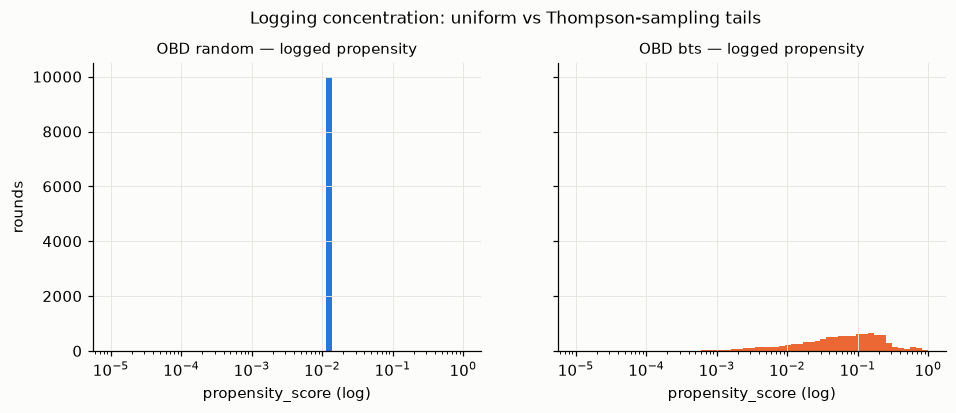

In [4]:
if HAS_OBD:
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.4), sharey=True)
    bins = np.logspace(-5, 0, 60)
    for ax, (pol, df) in zip(axes, obd.items()):
        ax.hist(df["propensity_score"], bins=bins, color=ACCENT if pol == "random" else ACCENT2)
        ax.set_xscale("log")
        ax.set_title(f"OBD {pol} — logged propensity", fontsize=10)
        ax.set_xlabel("propensity_score (log)")
    axes[0].set_ylabel("rounds")
    fig.suptitle("Logging concentration: uniform vs Thompson-sampling tails", y=1.02, fontsize=11)
    plt.show()

random 로그는 propensity 가 균일(≈1/80×position 보정)해 어떤 평가 정책이든 weight 가 유계다.
bts 로그는 확신에 찬 정책이라 **아이템별 확률이 4~5 자릿수를 오간다** — 여기서 uniform
정책을 평가하면 w=π_e/π_0 의 꼬리가 그대로 추정 분산이 된다. 세 번째 관점 — **커버리지**:
아이템 노출의 long-tail 을 보면 bts 가 일부 아이템에 노출을 몰아준 것이 보인다.

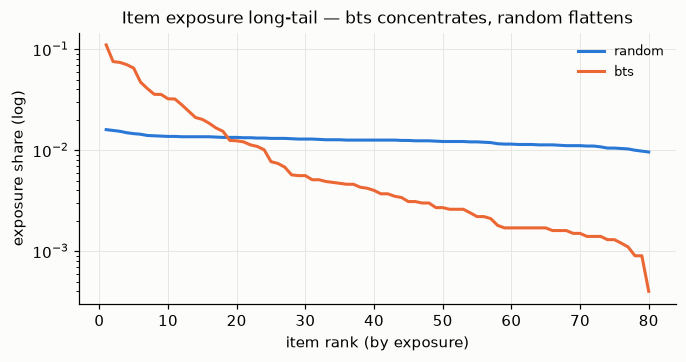

In [5]:
if HAS_OBD:
    fig, ax = plt.subplots(figsize=(7, 3.2))
    for pol, color in (("random", ACCENT), ("bts", ACCENT2)):
        share = obd[pol]["item_id"].value_counts(normalize=True).sort_values(ascending=False)
        ax.plot(np.arange(1, len(share) + 1), share.values, color=color, lw=2, label=f"{pol}")
    ax.set_yscale("log")
    ax.set_xlabel("item rank (by exposure)")
    ax.set_ylabel("exposure share (log)")
    ax.set_title("Item exposure long-tail — bts concentrates, random flattens", fontsize=11)
    ax.legend()
    plt.show()

마지막으로 세 관점을 한 수치로 잇는 **사고 실험**: 이 bts 로그로 uniform 정책(π_e=1/80)을
평가한다면 weight 분포가 어떻게 되나 — 축 12 프로토콜의 재현이다(탐색 지위).

In [6]:
if HAS_OBD:
    df = obd["bts"]
    w = (1.0 / df["item_id"].nunique()) / df["propensity_score"].to_numpy()
    ess_ratio = (w.sum() ** 2 / (w ** 2).sum()) / len(w)
    print(f"uniform-target weights on bts log:  max w = {w.max():,.1f}   "
          f"ESS ratio = {ess_ratio:.3f}  (n = {len(w):,})")
    print("클릭 1개가 짊어지는 최대 기여 = max w / n =", f"{w.max() / len(w):.2%}")

uniform-target weights on bts log:  max w = 277.8   ESS ratio = 0.034  (n = 10,000)
클릭 1개가 짊어지는 최대 기여 = max w / n = 2.78%


ESS ratio 가 낮고 max weight 가 수백이면, 클릭 몇 개가 추정치를 좌우한다 — 게이트가
DISTRUST 를 내리는 로그의 전형이다(정본 판정·수치는 LEDGER `m3-12-gate-demo` 행과
`results/tables/12_obd_small_gate.csv`).

## B. classification-to-bandit — 깨끗한 참값을 가진 4종 벤치

OpenML 분류 데이터셋을 밴딧化한다: 라벨 = 정답 행동, reward = 1[a=y], 로깅/평가 정책은
같은 스코어의 softmax 온도쌍(β_log=2 → β_eval=6). **propensity 도 참값도 정확**하므로
estimator 를 깨끗하게 채점할 수 있다(축 11 의 무대). 여기서는 로그 자체의 기하 —
스코어 분포·overlap·weight — 만 본다.

In [7]:
from ope.datasets import C2B_DATASETS, classification_to_bandit  # noqa: E402

c2b = {name: classification_to_bandit(name, seed=0, data_home=str(ROOT / "data" / "openml"))
       for name in C2B_DATASETS}
rows = []
for name, d in c2b.items():
    idx = np.arange(len(d.action))
    w = d.pi_e_dist[idx, d.action] / d.pscore
    rows.append({
        "dataset": name, "n": len(d.action), "K": d.n_actions,
        "logging_acc": d.reward.mean(),          # reward=1[a=y] ⇒ 로깅 정책 정답률
        "gt_value": d.gt_value,                  # 평가 정책 참값(정확)
        "max_w": w.max(), "ess_ratio": (w.sum() ** 2 / (w ** 2).sum()) / len(w),
    })
c2b_summary = pd.DataFrame(rows).set_index("dataset")
display(c2b_summary.style.format({"logging_acc": "{:.3f}", "gt_value": "{:.3f}",
                                  "max_w": "{:.2f}", "ess_ratio": "{:.3f}"}))

,n,K,logging_acc,gt_value,max_w,ess_ratio
dataset,,,,,,
optdigits,2810,10,0.425,0.938,2.93,0.462
satimage,3215,6,0.478,0.818,2.26,0.581
pendigits,5496,10,0.405,0.903,2.98,0.462
letter,10000,26,0.135,0.580,5.21,0.309


`gt_value` 열이 이 트랙의 존재 이유다 — **전 라벨을 아는 정확 참값**(`gt_ci=None`,
`src/ope/datasets.py` 의 의미 분리 규약). OBD 의 근사 참값(±bootstrap CI)과 정직성 지위가
다르다. weight 기하를 겹쳐 보면 네 데이터셋의 overlap 스트레스가 한눈에 비교된다.

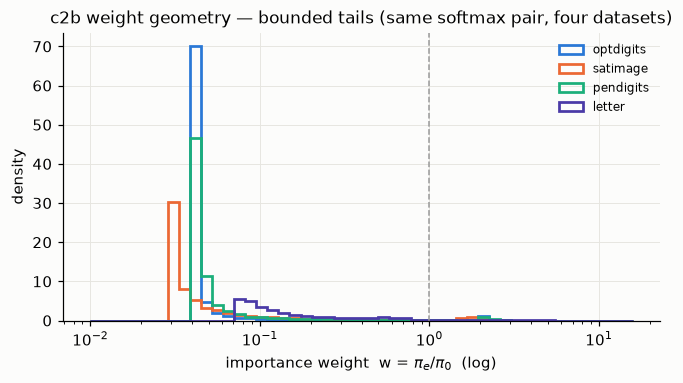

In [8]:
fig, ax = plt.subplots(figsize=(7, 3.4))
colors = [ESTIMATOR_COLORS[k] for k in ("dm", "ips", "snips", "dros")]
bins = np.logspace(-2, 1.2, 50)
for (name, d), color in zip(c2b.items(), colors):
    idx = np.arange(len(d.action))
    w = d.pi_e_dist[idx, d.action] / d.pscore
    ax.hist(w, bins=bins, histtype="step", lw=1.8, color=color, label=name, density=True)
ax.axvline(1.0, color=GRAY, lw=1, ls="--")
ax.set_xscale("log")
ax.set_xlabel("importance weight  w = $\\pi_e$/$\\pi_0$  (log)")
ax.set_ylabel("density")
ax.set_title("c2b weight geometry — bounded tails (same softmax pair, four datasets)", fontsize=11)
ax.legend(fontsize=8)
plt.show()

## C. 정리 — 로그 EDA 가 OPE 에 말해주는 것

| 관점 | OBD bts 실로그 | c2b 4종 | OPE 에의 함의 |
|---|---|---|---|
| reward 희소성 | CTR 0.38–0.42% (§A 표) — 유효 정보 = 클릭 수 | 정답률 13.5–47.8% (§B 표) — 정보 풍부 | 분산의 분모, 판별력의 상한 |
| propensity | 1e-4 급 꼬리 (실측) | 정확·유계 | 꼬리 = weight 폭발 = ESS 붕괴 |
| 커버리지 | 노출 long-tail 집중 | softmax 쌍 = 전 행동 지지 | 미지지 행동 = 어떤 estimator 도 못 구함 |

이 세 열이 곧 진단 3종(ESS·max-weight·support proxy, `src/ope/diagnostics.py`)의 데이터적
기원이다 — 03권에서 계산 과정을 해부한다. 로그의 기하가 estimator 성적을 어떻게 가르는지의
**정본 채점표**는 축 11(`m3-11-dr-robust`)·축 12(`m3-12-gate-demo`)와
[`docs/PLAYBOOK.md`](../docs/PLAYBOOK.md) 에 있다.